In [5]:
%pip install tensorflow

  Using cached tensorflow-2.20.0-cp312-cp312-macosx_12_0_arm64.whl.metadata (4.5 kB)
  Using cached absl_py-2.3.1-py3-none-any.whl.metadata (3.3 kB)
  Using cached astunparse-1.6.3-py2.py3-none-any.whl.metadata (4.4 kB)
  Using cached flatbuffers-25.12.19-py2.py3-none-any.whl.metadata (1.0 kB)
  Using cached gast-0.7.0-py3-none-any.whl.metadata (1.5 kB)
  Using cached google_pasta-0.2.0-py3-none-any.whl.metadata (814 bytes)
  Using cached libclang-18.1.1-1-py2.py3-none-macosx_11_0_arm64.whl.metadata (5.2 kB)
  Using cached tensorboard-2.20.0-py3-none-any.whl.metadata (1.8 kB)
  Using cached keras-3.13.0-py3-none-any.whl.metadata (6.3 kB)
  Using cached markdown-3.10-py3-none-any.whl.metadata (5.1 kB)
  Using cached tensorboard_data_server-0.7.2-py3-none-any.whl.metadata (1.1 kB)
  Using cached werkzeug-3.1.4-py3-none-any.whl.metadata (4.0 kB)
  Using cached wheel-0.45.1-py3-none-any.whl.metadata (2.3 kB)
  Using cached namex-0.1.0-py3-none-any.whl.metadata (322 bytes)
Using cached tens

In [5]:
import os
import pathlib
import shutil
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models

# ==============================================================================
# 1. 데이터 다운로드 및 "진짜" 경로 찾기 (수정됨)
# ==============================================================================
print("1. 데이터셋 준비 및 경로 탐색 중...")

# 캐시 디렉토리 설정 (현재 폴더의 data 폴더)
cache_dir = pathlib.Path('./data')
if not cache_dir.exists():
    os.makedirs(cache_dir)

# 파일 다운로드 (이미 있으면 스킵)
zip_path = tf.keras.utils.get_file(
    'mini_speech_commands.zip',
    origin='http://storage.googleapis.com/download.tensorflow.org/data/mini_speech_commands.zip',
    extract=True,
    cache_dir='.', cache_subdir='data'
)

# [핵심 수정] 압축 풀린 폴더 위치를 'rglob'으로 직접 찾습니다.
# 'down'이라는 폴더가 있는 곳이 바로 데이터 루트입니다.
base_dir = pathlib.Path(os.path.dirname(zip_path))
found_class_folders = list(base_dir.rglob('down')) # 'down' 폴더를 재귀적으로 검색

if not found_class_folders:
    # 만약 못 찾았다면, 기존 data 폴더가 꼬였을 수 있으니 삭제 후 재시도 안내
    try:
        shutil.rmtree(cache_dir)
    except:
        pass
    raise ValueError("데이터 폴더 구조가 꼬였습니다. 'data' 폴더를 삭제하고 코드를 다시 실행해주세요.")

# 데이터 루트 확정 (예: data/mini_speech_commands)
data_root = found_class_folders[0].parent
print(f"   - 데이터 위치 확인 완료: {data_root}")

# 5개 클래스 정의
target_commands = np.array(['down', 'go', 'left', 'no', 'right'])

# 해당 경로에서 모든 wav 파일 긁어오기
all_file_paths = list(data_root.glob('*/*.wav'))
all_file_paths = [str(path) for path in all_file_paths] # 문자열 변환

# 5개 클래스만 필터링
labeled_files = []
for fpath in all_file_paths:
    label = pathlib.Path(fpath).parent.name
    if label in target_commands:
        labeled_files.append(fpath)

# 랜덤 셔플 (Numpy 사용)
labeled_files = np.array(labeled_files)
np.random.shuffle(labeled_files)

print(f"   - 총 사용할 파일 수: {len(labeled_files)}개")

# 학습/테스트 분리
train_files = labeled_files[:int(len(labeled_files)*0.8)]
test_files = labeled_files[int(len(labeled_files)*0.8):]

# ==============================================================================
# 2. 전처리 파이프라인
# ==============================================================================
print("2. 데이터 파이프라인 구축 중...")

def get_spectrogram(audio):
    input_len = 16000
    audio = audio[:input_len]
    zero_padding = tf.zeros([16000] - tf.shape(audio), dtype=tf.float32)
    audio = tf.cast(audio, dtype=tf.float32)
    equal_length = tf.concat([audio, zero_padding], 0)
    spectrogram = tf.signal.stft(equal_length, frame_length=255, frame_step=128)
    spectrogram = tf.abs(spectrogram)
    spectrogram = spectrogram[..., tf.newaxis]
    return spectrogram

def preprocess_file(file_path):
    # 라벨 추출 (텐서 연산)
    parts = tf.strings.split(file_path, os.path.sep)
    label = parts[-2]
    label_id = tf.argmax(label == target_commands)
    
    # 오디오 로드 및 변환
    audio_binary = tf.io.read_file(file_path)
    audio, _ = tf.audio.decode_wav(audio_binary)
    audio = tf.squeeze(audio, axis=-1)
    spectrogram = get_spectrogram(audio)
    
    return spectrogram, label_id

def make_ds(files):
    files_ds = tf.data.Dataset.from_tensor_slices(files)
    output_ds = files_ds.map(preprocess_file, num_parallel_calls=tf.data.AUTOTUNE)
    output_ds = output_ds.batch(32).cache().prefetch(tf.data.AUTOTUNE)
    return output_ds

train_ds = make_ds(train_files)
test_ds = make_ds(test_files)

# 입력 shape 가져오기
for spec, _ in train_ds.take(1):
    input_shape = spec.shape[1:]

# ==============================================================================
# 3. 모델 정의 (100KB 이하) 및 학습
# ==============================================================================
print("3. 모델 학습 시작...")

model = models.Sequential([
    layers.Input(shape=input_shape),
    layers.Resizing(32, 32),
    layers.Normalization(),
    
    layers.Conv2D(32, 3, activation='relu', padding='same'),
    layers.MaxPooling2D(),
    
    layers.Conv2D(64, 3, activation='relu', padding='same'),
    layers.MaxPooling2D(),
    
    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.2),
    layers.Dense(len(target_commands), activation='softmax')
])

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

model.summary()
total_params = model.count_params()
print(f"\n[결과] 총 파라미터: {total_params} (약 {total_params*4/1024:.1f} KB)")

history = model.fit(train_ds, validation_data=test_ds, epochs=20)

loss, acc = model.evaluate(test_ds)
print(f"\n최종 테스트 정확도: {acc*100:.2f}%")

1. 데이터셋 준비 및 경로 탐색 중...
   - 데이터 위치 확인 완료: data/mini_speech_commands_extracted/mini_speech_commands
   - 총 사용할 파일 수: 5000개
2. 데이터 파이프라인 구축 중...
3. 모델 학습 시작...


2025-12-26 23:00:04.276563: W tensorflow/core/kernels/data/cache_dataset_ops.cc:917] The calling iterator did not fully read the dataset being cached. In order to avoid unexpected truncation of the dataset, the partially cached contents of the dataset  will be discarded. This can happen if you have an input pipeline similar to `dataset.cache().take(k).repeat()`. You should use `dataset.take(k).cache().repeat()` instead.
2025-12-26 23:00:04.277502: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resizing_1 (Resizing)           │ (None, 32, 32, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ normalization_1 (Normalization) │ (None, 32, 32, 1)      │             3 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 64)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,144 (74.79 KB)

 Trainable params: 19,141 (74.77 KB)

 Non-trainable params: 3 (16.00 B)


[결과] 총 파라미터: 19144 (약 74.8 KB)
Epoch 1/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.2677 - loss: 1.5929 - val_accuracy: 0.4480 - val_loss: 1.5449
Epoch 2/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.3577 - loss: 1.5236 - val_accuracy: 0.4700 - val_loss: 1.4455
Epoch 3/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.4140 - loss: 1.4406 - val_accuracy: 0.5200 - val_loss: 1.3582
Epoch 4/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.4455 - loss: 1.3717 - val_accuracy: 0.5280 - val_loss: 1.2982
Epoch 5/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.4760 - loss: 1.3221 - val_accuracy: 0.5680 - val_loss: 1.2472
Epoch 6/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.5063 - loss: 1.2811 - val_accuracy: 0.5910 - val_loss: 1.2131
Epoch 7/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.5408 - loss: 1.2450 - val_accuracy: 0.6330 - val_loss: 1.1741
Epoch 8/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.5735 

Plot saved as 'dnn_accuracy_comparison.png'


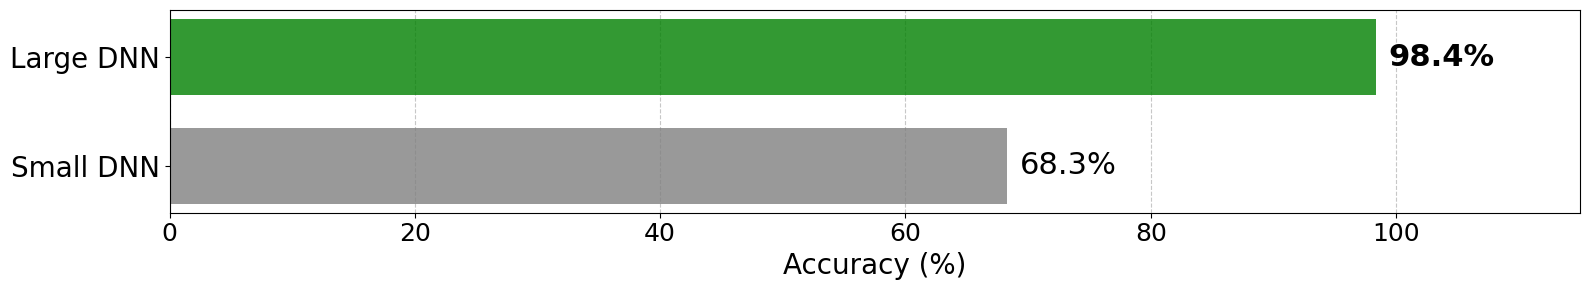

In [4]:
import matplotlib.pyplot as plt
import numpy as np

def plot_dnn_accuracy_comparison_horizontal():
    # ==========================================
    # DNN Accuracy Data
    # ==========================================
    dnn_types = ['Small DNN', 'Large DNN']
    accuracies = [68.3, 98.4]  # Accuracy in percentage (kept from existing cell)

    # ==========================================
    # PLOTTING (Horizontal Bars)
    # ==========================================
    fig, ax = plt.subplots(figsize=(16, 3))

    y = np.arange(len(dnn_types))
    height = 0.7  # keep spacing tight (not intentionally increased)

    # Create horizontal bars with different colors
    colors = ['gray', 'green']
    bars = ax.barh(y, accuracies, height=height, color=colors, alpha=0.8)

    # Formatting
    ax.set_xlabel('Accuracy (%)', fontsize=20)
    ax.tick_params(axis='x', labelsize=18)
    ax.tick_params(axis='y', labelsize=20)
    ax.set_xlim(0, 115)
    ax.xaxis.grid(True, linestyle='--', alpha=0.7)
    ax.set_axisbelow(True)

    # Y-axis formatting (keep original ordering)
    ax.set_yticks(y)
    ax.set_yticklabels(dnn_types, fontsize=20)

    # Annotate bars with values to the right of the bar
    for i, (bar, acc) in enumerate(zip(bars, accuracies)):
        fontweight = 'bold' if i == 1 else 'normal'  # Bold for Large DNN
        # x position: bar width + small offset
        ax.text(bar.get_width() + 1.0, bar.get_y() + bar.get_height() / 2,
                f'{acc}%', ha='left', va='center', fontsize=22, fontweight=fontweight)

    plt.tight_layout()

    save_path = 'dnn_accuracy_comparison.png'
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    print(f"Plot saved as '{save_path}'")
    plt.show()

# Run the function
plot_dnn_accuracy_comparison_horizontal()